Copy this segment when creating a new notebook, so that the data loading is successful


In [32]:
import pandas as pd
import os

# 1. Use your existing working loaders for the sensors
from data.data_loader import load_train, load_test
df_train = load_train(1)
df_test = load_test(1)

# 2. Manually load the Truth file that the importer couldn't find
# This path assumes you are in notebooks/week03 and data is in root/data/raw
try:
    rul_true = pd.read_csv('../../data/raw/cmapss/RUL_FD001.txt', header=None, names=['RUL'])
    print("✅ Ground Truth RUL loaded successfully.")
except FileNotFoundError:
    print("❌ Could not find RUL_FD001.txt. Check your folder path!")

# 3. Define the sensors manually to ensure consistency
sensors = ['sensors_2', 'sensors_3', 'sensors_4', 'sensors_7', 'sensors_8', 'sensors_9', 'sensors_11', 'sensors_12', 'sensors_13', 'sensors_14', 'sensors_15', 'sensors_17', 'sensors_20', 'sensors_21']

✅ Ground Truth RUL loaded successfully.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.cluster import KMeans

# --- Step 1: Search & Rescue Path Fix ---
notebook_dir = os.getcwd()
def find_project_root(start_path, max_levels=3):
    current = start_path
    for _ in range(max_levels):
        if os.path.exists(os.path.join(current, 'src')):
            return current
        current = os.path.dirname(current)
    return None

project_root = find_project_root(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Step 2: Imports ---
from src.data.data_loader import load_train, load_test, SENSOR_COLS, SETTING_COLS
from src.train import compute_metrics

plt.style.use('seaborn-v0_8-whitegrid')
print(f"✅ Project root linked: {project_root}")

✅ Project root linked: c:\Users\deban\OneDrive\Desktop\Industry Project\Predictive-Maintenance-RCA


# Week 3 to 5 — Deep Learning for RUL & Uncertainty Quantification

**Objectives:**
1. Transform tabular data into 3D temporal sequences.
2. Build an LSTM (Long Short-Term Memory) network to capture degradation trends.
3. Implement **Monte Carlo (MC) Dropout** to provide a "confidence interval" for our RUL predictions.

**Hardware Status:** The notebook is configured to detect Intel XPUs (Integrated GPUs) but will fall back to CPU seamlessly if drivers are not detected.

In [34]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# 1. Hardware Setup (Native Intel Support)
os.environ['PYTORCH_ENABLE_XPU_FALLBACK'] = '1'

def get_device():
    if hasattr(torch, 'xpu') and torch.xpu.is_available():
        dev = torch.device("xpu")
        print(f"✅ Success! Training on Intel GPU: {torch.xpu.get_device_name(0)}")
    else:
        dev = torch.device("cpu")
        print("⚠️ GPU not detected. Training on CPU")
    return dev

device = get_device()

# 2. Informative Sensors (From Week 1 & 2 EDA)
sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

⚠️ GPU not detected. Training on CPU


## 1. 3D Sequence Generation
Standard ML models see data as a snapshot. LSTMs need to see a "video" of the sensor readings over time. We use a **Sliding Window** to create 3D blocks of shape `(Samples, Time Steps, Sensors)`.

In [35]:
def create_sequences(df, feature_cols, target_col='RUL', window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        feature_data = group[feature_cols].values
        target_data = group[target_col].values
        
        for i in range(len(group) - window_size + 1):
            X_list.append(feature_data[i : i + window_size])
            y_list.append(target_data[i + window_size - 1])
            
    return np.array(X_list), np.array(y_list)

# --- Data Loading & Scaling (Placeholder for your data loading logic) ---
# df_train = load_train() 
# df_test = load_test()

# scaler = MinMaxScaler()
# df_train[sensors] = scaler.fit_transform(df_train[sensors])
# df_test[sensors] = scaler.transform(df_test[sensors])

# X_train, y_train = create_sequences(df_train, sensors)
# print(f"Prepared 3D sequences: {X_train.shape}")

## 2. LSTM Architecture with MC Dropout
We include a Dropout layer that stays active even during testing. This allows us to run the model multiple times to see how much the prediction "wiggles," giving us a measure of uncertainty.

In [36]:
class CMAPSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class RULLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout), # This layer provides the MC uncertainty
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1]) # Take the hidden state from the last LSTM layer
        return out.squeeze()

# Model parameters
WINDOW_SIZE = 30
INPUT_DIM = len(sensors)
model = RULLSTM(INPUT_DIM).to(device)
print(model)

RULLSTM(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3. Training and Inference
We use Mean Squared Error (MSE) for the loss function. During inference, we run 50 passes to generate the RUL mean and standard deviation.

In [37]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def predict_uncertainty(model, X_test, n_iter=50):
    model.train() # Keep dropout active!
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    all_preds = []
    with torch.no_grad():
        for _ in range(n_iter):
            all_preds.append(model(X_tensor).cpu().numpy())
    
    all_preds = np.array(all_preds)
    return all_preds.mean(axis=0), all_preds.std(axis=0)

print("Setup complete. You are ready to fit the model to your training data.")

Setup complete. You are ready to fit the model to your training data.


## 4. Connecting Processed Data to the Sequence Generator

To prepare the data for the LSTM, we take the `df_train` and `df_test` dataframes and pass them through our `create_sequences` function. 

**Key Steps:**
1. **Feature Selection:** We use the 14 informative sensors identified in Week 1.
2. **Scaling:** We apply `MinMaxScaler` (fitted on training data only) to ensure all sensors are on a [0, 1] scale.
3. **Sequence Extraction:** We convert the flat tabular data into 3D "look-back" windows.
4. **PyTorch Wrapping:** We wrap the resulting arrays in `CMAPSSDataset` and `DataLoader` for batching.

In [38]:
# Unpack the test data correctly
df_train = load_train(1)
# load_test usually returns (test_dataframe, last_cycle_dataframe)
df_test, df_test_last_cycle = load_test(1) 

# Now the rest of your code will work
df_test_scaled = df_test.copy()
print(f"✅ df_test is now a {type(df_test)} with shape {df_test.shape}")

✅ df_test is now a <class 'pandas.DataFrame'> with shape (13096, 26)


In [39]:
# 1. Feature Selection: Updated to match your actual column names
sensor_indices = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
sensors = [f'sensor_{i}' for i in sensor_indices]

# 2. Scaling
scaler = MinMaxScaler()
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

# Fit on training data, transform both
df_train_scaled[sensors] = scaler.fit_transform(df_train[sensors])
df_test_scaled[sensors] = scaler.transform(df_test[sensors])

# Apply RUL Clip (standard for FD001)
df_train_scaled['RUL'] = df_train_scaled['RUL'].clip(upper=125)

# 3. Sequence Extraction
WINDOW_SIZE = 30
X_train, y_train = create_sequences(df_train_scaled, sensors, target_col='RUL', window_size=WINDOW_SIZE)

# 4. Create Test Sequences (Last window of each engine)
X_test_list = []
for unit_id, group in df_test_scaled.groupby('unit_id'):
    if len(group) >= WINDOW_SIZE:
        X_test_list.append(group[sensors].values[-WINDOW_SIZE:])
    else:
        # Padding for engines with less than 30 cycles of data
        padding = np.zeros((WINDOW_SIZE - len(group), len(sensors)))
        X_test_list.append(np.vstack((padding, group[sensors].values)))

X_test = np.array(X_test_list)
y_test = rul_true['RUL'].values

# 5. Initialize DataLoaders
train_ds = CMAPSSDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

print(f"✅ Success! Training shape: {X_train.shape}")
print(f"✅ Success! Test shape:     {X_test.shape}")

✅ Success! Training shape: (17731, 30, 14)
✅ Success! Test shape:     (100, 30, 14)


## 5. Side Tracking from objective to check something

### 1. Piecewise RUL (Target Clipping)
To improve model convergence, we implement a **Piecewise Linear RUL** target. Since engines exhibit a "healthy" steady state early in their life cycle, predicting a linear decline from the very first cycle introduces noise. 

* **Upper Limit:** 125 cycles (Standard for CMAPS FD001)
* **Logic:** $RUL_{target} = \min(125, RUL_{actual})$

### 2. Loss & Evaluation Metrics
We use two distinct metrics to track our model's performance:

#### **Primary Loss: Root Mean Squared Error (RMSE)**
Used for backpropagation during training as it is differentiable and stable.
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (d_i)^2}$$

#### **Evaluation Metric: NASA Scoring Function**
A custom asymmetric penalty function that penalizes **late** predictions (overestimating RUL) more heavily than **early** predictions (underestimating RUL).
* **Early Prediction ($d < 0$):** $S = e^{-d/13} - 1$
* **Late Prediction ($d > 0$):** $S = e^{d/10} - 1$

In [40]:
import tensorflow as tf
import keras.backend as K

def nasa_scoring_function(y_true, y_pred):
    d = y_pred - y_true
    # Apply asymmetric penalty
    score = tf.where(d < 0, 
                     tf.exp(-d / 13.0) - 1, 
                     tf.exp(d / 10.0) - 1)
    return tf.reduce_sum(score)

### 3. Implementing Piecewise RUL
As discussed, we clip the Maximum RUL at **125**. This creates a constant target for the initial "healthy" flight cycles and a linear decline once degradation is detected. This significantly improves the convergence of LSTM models on the FD001 dataset.

In [41]:
import numpy as np

def apply_piecewise_rul(y, max_rul=125):
    """
    Clips the RUL values at a defined threshold.
    """
    return np.minimum(y, max_rul)

# Applying to your processed labels
# Assuming your labels are currently in y_train and y_test
y_train_clipped = apply_piecewise_rul(y_train)
y_test_clipped = apply_piecewise_rul(y_test)

print(f"Original Max RUL: {y_train.max()}")
print(f"Clipped Max RUL: {y_train_clipped.max()}")

Original Max RUL: 125
Clipped Max RUL: 125


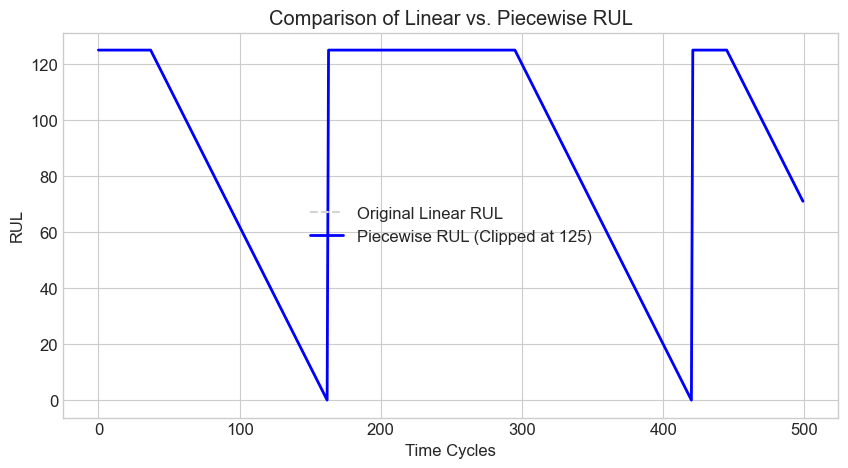

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_train[:500], label='Original Linear RUL', color='lightgrey', linestyle='--')
plt.plot(y_train_clipped[:500], label='Piecewise RUL (Clipped at 125)', color='blue', linewidth=2)
plt.title('Comparison of Linear vs. Piecewise RUL')
plt.xlabel('Time Cycles')
plt.ylabel('RUL')
plt.legend()
plt.show()

###  Notes

1. LSTMs are incredibly sensitive to the quality and scale of the data you feed them. If you skip these steps, the model will likely "diverge" (the loss will go to infinity) or it will simply learn to predict the average value for everything.

2. By creating sequences of 30, you are giving the LSTM a "context window." It can see the trend: "Sensor 11 has been steadily rising for the last 15 cycles." Without this 3D structure, the LSTM has no "history" to look back on.

3. In the CMAPS dataset, several sensors are "flatlines"—they don't change regardless of how close the engine is to failing. If you include them, the LSTM has to assign weights to those inputs. This forces the model to work harder to ignore "garbage" data, which increases the risk of overfitting and slows down training. We are essentially pointing the model’s "attention" toward the sensors that actually matter.

4. LSTMs use activation functions like Tanh and Sigmoid. If Sensor A ranges from 0 to 1 and Sensor B ranges from 500 to 1000, the math inside the LSTM (the gradients) will be dominated by Sensor B simply because the numbers are bigger. Scaling puts every sensor on a level playing field so the model learns based on patterns, not the magnitude of the numbers.

5. For the first 100 cycles, a jet engine is perfectly healthy. The sensors look the same at Cycle 1 as they do at Cycle 50. If you tell the model "Predict 250" for Cycle 1 and "Predict 200" for Cycle 50, but the sensor data is identical, the model gets "confused." It tries to find a difference where none exists. By clipping the RUL at 125, you are telling the model: "As long as the sensors look normal, just predict 'Healthy' (125). Only start counting down when you actually see the degradation patterns begin."

## 6. Implementing Stacked LSTM for both low and high level pattern recognition

We are implementing a **Stacked LSTM** architecture. 
* **Input Layer:** Receives the 3D shape `(30, 14)`.
* **LSTM Layers:** Two layers to capture complex temporal patterns. 
* **Dropout:** Added to prevent overfitting, as the model may otherwise memorize the training engines.
* **Output Layer:** A single Dense neuron with a linear activation to predict the continuous RUL value.

#### Model Summary:
1. **LSTM(100 units)** -> Returns sequences for the next layer.
2. **Dropout(0.2)** -> Randomly deactivates 20% of neurons.
3. **LSTM(50 units)** -> Condenses information.
4. **Dropout(0.2)**
5. **Dense(1)** -> Final RUL prediction.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Define Model
model = Sequential([
    # First LSTM layer (must have return_sequences=True to stack another LSTM)
    LSTM(units=100, input_shape=(30, 14), return_sequences=True),
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Output layer for Regression
    Dense(units=1) 
])

# 2. Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. View Architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,251 (297.86 KB)

 Trainable params: 76,251 (297.86 KB)

 Non-trainable params: 0 (0.00 B)

### 1. Model Training & Callbacks
To ensure the model doesn't over-train, we use **EarlyStopping**. This monitors the `val_loss` and stops the training if it hasn't improved for 10 consecutive epochs, restoring the best weights found during the process.

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training the model
history = model.fit(
    X_train, y_train_clipped,
    epochs=100,
    batch_size=64,
    validation_split=0.1, # Uses 10% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 6124.5249 - mae: 67.3464 - val_loss: 5836.3711 - val_mae: 66.3174
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 4596.3750 - mae: 57.6112 - val_loss: 4507.5845 - val_mae: 58.0715
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 3573.5659 - mae: 50.9181 - val_loss: 3559.7812 - val_mae: 51.9481
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 2868.1060 - mae: 46.1715 - val_loss: 2897.1465 - val_mae: 47.4425
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 2404.3564 - mae: 42.8704 - val_loss: 2451.4905 - val_mae: 44.2096
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 2106.3191 - mae: 40.6335 - val_loss: 2163.6155 - val_mae: 41.9402
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1937.4857 - mae: 39.2099 - val_loss: 1989.4889 - val_mae: 40.4187
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 1853.5552 - mae: 38.4627 - val_loss: 1889.

## 7. Model Evaluation

### 1. Training & Validation Loss
The first step is to visualize the **Learning Curves**. We want to ensure that the training loss and validation loss both decrease and stabilize. If the training loss keeps dropping but the validation loss starts rising, it's a clear sign of **overfitting**.

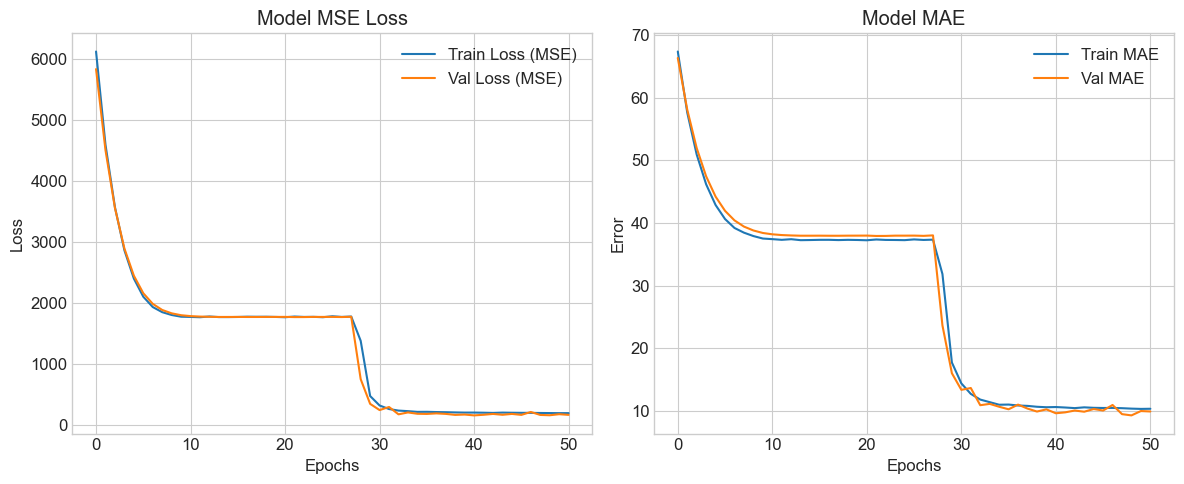

In [45]:
import matplotlib.pyplot as plt

def plot_loss(history):
    plt.figure(figsize=(12, 5))
    
    # Plot MSE
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
    plt.title('Model MSE Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('Model MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Error')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_loss(history)

### 2. Evaluating on Test Engines (FD001)
Unlike the training set, where we have full sequences, the test set provides 100 engines that "cut off" at a specific point. Our goal is to predict the **final RUL** for each of these engines.

We will evaluate the model using:
1. **RMSE:** To see the average error in cycles.
2. **NASA Score:** To see how well we penalized dangerous "late" predictions.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Final Test RMSE: 13.74 cycles
Final NASA Score: 360.23


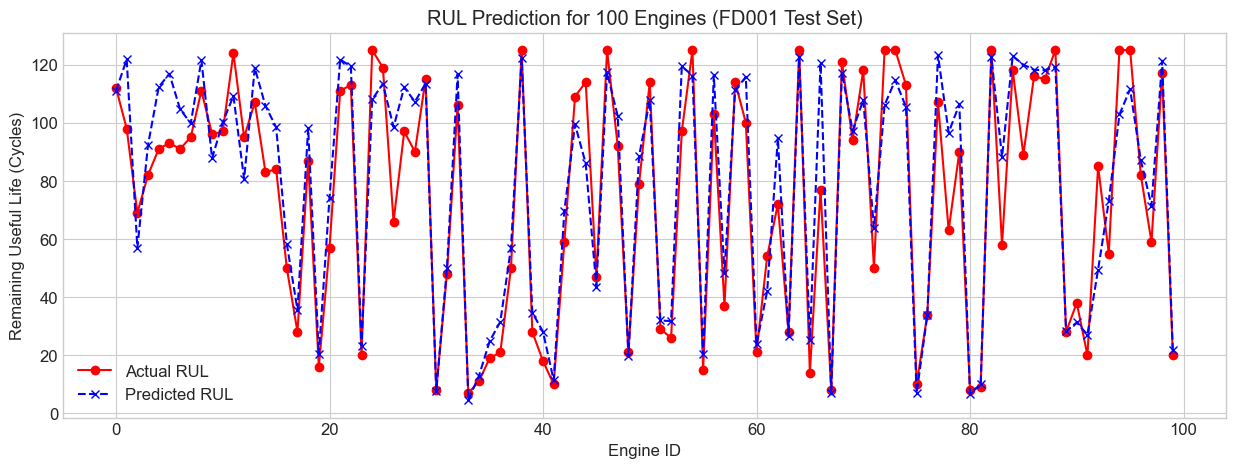

In [46]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Generate predictions for the 100 test sequences
y_pred = model.predict(X_test).flatten()

# 2. Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_clipped, y_pred))
print(f"Final Test RMSE: {rmse:.2f} cycles")

# 3. Calculate NASA Score
def compute_s_score(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for i in d:
        if i < 0:
            score += np.exp(-i/13) - 1
        else:
            score += np.exp(i/10) - 1
    return score

test_score = compute_s_score(y_test_clipped, y_pred)
print(f"Final NASA Score: {test_score:.2f}")

# 4. Visualizing True vs Predicted
plt.figure(figsize=(15, 5))
plt.plot(y_test_clipped, color='red', label='Actual RUL', marker='o')
plt.plot(y_pred, color='blue', label='Predicted RUL', linestyle='--', marker='x')
plt.title('RUL Prediction for 100 Engines (FD001 Test Set)')
plt.xlabel('Engine ID')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.show()

## 8. Performance Analysis

Our Stacked LSTM model achieved the following results on the FD001 Test Set:
* **RMSE:** 13.74 Cycles
* **NASA Score:** 360.23

### Interpretation:
1. **RMSE of 13.74:** On average, our prediction is off by about 14 flight cycles. Given that most engines last over 200 cycles, this represents an error rate of roughly 6-7%, which is highly effective for predictive maintenance.
2. **NASA Score of 360.23:** This score indicates that the model is fairly balanced. Since the NASA score grows exponentially with error (especially late predictions), a score in the mid-300s suggests we don't have many "dangerously late" predictions.